# Monitoring Habitat Fragmentation Using Remote Sensing

**Project Overview:** Analysis of urban habitat fragmentation in Rajkot and Ahmedabad using Sentinel-2 satellite imagery and NDVI (Normalized Difference Vegetation Index).

---

## 📋 Table of Contents
1. [Introduction](#introduction)
2. [Technologies & Data Sources](#technologies)
3. [Methodology](#methodology)
4. [Google Earth Engine Analysis](#gee-analysis)
5. [NDVI Visualization](#visualization)
6. [Results & Findings](#results)
7. [Conclusions](#conclusions)

## 1. Introduction <a id="introduction"></a>

### What is Habitat Fragmentation?
Habitat fragmentation is the process by which continuous habitats are divided into smaller, isolated patches, primarily due to urbanization, deforestation, and infrastructure development. This phenomenon has significant ecological impacts:
- **Loss of biodiversity**
- **Disruption of ecosystem services**
- **Reduced species mobility**
- **Increased edge effects**

### Project Objectives
This project aims to:
1. Monitor vegetation health and distribution in urban areas
2. Calculate NDVI to assess green cover
3. Identify patterns of habitat fragmentation
4. Compare fragmentation between Rajkot and Ahmedabad regions

### Study Areas
- **Rajkot**: Major city in Gujarat, India
- **Ahmedabad**: Largest city in Gujarat, India

## 2. Technologies & Data Sources <a id="technologies"></a>

### Technologies Used
- **Google Earth Engine (GEE)**: Cloud-based platform for planetary-scale geospatial analysis
- **JavaScript (GEE API)**: For satellite data processing and NDVI calculation
- **Python**: For data visualization and analysis
- **Sentinel-2 L2A**: High-resolution multispectral satellite imagery

### Data Sources
- **Satellite Imagery**: Copernicus Sentinel-2 Surface Reflectance (L2A)
  - Temporal Range: 2020-2023
  - Spatial Resolution: 10m
  - Spectral Bands: 13 bands including NIR and Red
- **Boundary Data**: GeoJSON files for study area boundaries

### Key Libraries

In [1]:
# Import required Python libraries
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import geopandas as gpd
import json

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 3. Methodology <a id="methodology"></a>

### NDVI (Normalized Difference Vegetation Index)

NDVI is a widely used vegetation index that measures the health and density of vegetation using satellite imagery.

**Formula:**

$$NDVI = \frac{NIR - Red}{NIR + Red}$$

Where:
- **NIR**: Near-Infrared reflectance (Band 8 in Sentinel-2)
- **Red**: Red reflectance (Band 4 in Sentinel-2)

### NDVI Value Interpretation

| NDVI Range | Description | Interpretation |
|------------|-------------|----------------|
| -1 to 0    | Non-vegetated | Water, snow, clouds, bare soil |
| 0 to 0.2   | Sparse vegetation | Urban areas, rocky surfaces |
| 0.2 to 0.4 | Moderate vegetation | Shrubs, grassland |
| 0.4 to 0.6 | Dense vegetation | Crops, forests |
| 0.6 to 1   | Very dense vegetation | Tropical forests, healthy crops |

### Workflow
1. **Data Acquisition**: Load Sentinel-2 imagery from Google Earth Engine
2. **Preprocessing**: Apply cloud and snow masking
3. **NDVI Calculation**: Compute NDVI using NIR and Red bands
4. **Temporal Aggregation**: Calculate mean NDVI over 3-year period
5. **Export**: Save processed data as GeoTIFF
6. **Visualization**: Create maps and analyze patterns

## 4. Google Earth Engine Analysis <a id="gee-analysis"></a>

### Cloud Masking & Preprocessing

Cloud masking is crucial for accurate NDVI calculation. We use Sentinel-2's quality bands:
- **MSK_CLDPRB**: Cloud probability mask
- **MSK_SNWPRB**: Snow probability mask

Below is the JavaScript code executed in Google Earth Engine:

```javascript
// ============================================
// GOOGLE EARTH ENGINE - RAJKOT ANALYSIS
// ============================================

// Load Rajkot boundary from GEE assets
var rajkotBoundary = ee.FeatureCollection(
  "projects/ee-manishkumarchoudhary122450/assets/rajkot_boundary"
);

// Function to mask clouds and snow
var maskClouds = function(image) {
  // Create mask for pixels with <50% cloud and snow probability
  var cloudMask = image.select('MSK_CLDPRB').lt(50)
      .and(image.select('MSK_SNWPRB').lt(50));
  
  // Apply mask and scale reflectance values (10000 scale factor)
  return image.updateMask(cloudMask).divide(10000);
};

// Load Sentinel-2 Surface Reflectance imagery
var sentinel = ee.ImageCollection('COPERNICUS/S2_SR')
  .filterBounds(rajkotBoundary)          // Filter by study area
  .filterDate('2020-01-01', '2023-01-01') // 3-year temporal window
  .map(maskClouds);                      // Apply cloud masking

// Function to calculate NDVI
var calculateNDVI = function(image) {
  // NDVI = (NIR - Red) / (NIR + Red)
  var ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI');
  
  // Add NDVI band to image and select relevant bands
  return image.addBands(ndvi).select([
    'NDVI', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 
    'B7', 'B8', 'B8A', 'B9', 'B11', 'B12'
  ]);
};

// Apply NDVI calculation to entire collection
var ndviCollection = sentinel.map(calculateNDVI);

// Calculate temporal mean NDVI and clip to boundary
var ndviMean = ndviCollection.mean()
  .select('NDVI')
  .clip(rajkotBoundary);

// Visualization parameters
var ndviVis = {
  min: 0, 
  max: 1, 
  palette: ['white', 'green']
};

// Display on map
Map.centerObject(rajkotBoundary, 10);
Map.addLayer(ndviMean, ndviVis, "NDVI - Rajkot");

// Export NDVI as GeoTIFF
Export.image.toDrive({
  image: ndviMean,
  description: 'Rajkot_NDVI',
  scale: 10,                    // 10m resolution
  region: rajkotBoundary.geometry(),
  fileFormat: 'GeoTIFF'
});
```

### Key Processing Steps Explained

1. **Cloud Masking (Line 9-15)**
   - Filters out pixels with >50% cloud/snow probability
   - Ensures clean, accurate vegetation readings
   - Scales reflectance values to 0-1 range

2. **NDVI Calculation (Line 25-26)**
   - Uses `normalizedDifference()` function
   - B8 (NIR) and B4 (Red) are Sentinel-2 bands
   - Output range: -1 to +1

3. **Temporal Aggregation (Line 37-39)**
   - Calculates mean NDVI across 3 years
   - Reduces seasonal variations
   - Provides stable vegetation baseline

4. **Export (Line 49-55)**
   - Exports at 10m spatial resolution
   - GeoTIFF format for further analysis
   - Same process repeated for Ahmedabad

## 5. NDVI Visualization <a id="visualization"></a>

### Load and Visualize Rajkot NDVI

In [2]:
# Define file paths
rajkot_ndvi_path = r"C:\Users\manis\OneDrive\Documents\College\Projects\Habitate-Fragmentation\Analysis\Rajkot_NDVI.tif"
ahmedabad_ndvi_path = r"C:\Users\manis\OneDrive\Documents\College\Projects\Habitate-Fragmentation\Analysis\AHEMDABAD_NDVI.tif"

# Load Rajkot NDVI data
with rasterio.open(rajkot_ndvi_path) as src:
    rajkot_ndvi = src.read(1)  # Read first band
    rajkot_meta = src.meta
    rajkot_bounds = src.bounds
    
print(f"Rajkot NDVI Shape: {rajkot_ndvi.shape}")
print(f"NDVI Range: {np.nanmin(rajkot_ndvi):.3f} to {np.nanmax(rajkot_ndvi):.3f}")
print(f"Mean NDVI: {np.nanmean(rajkot_ndvi):.3f}")

Rajkot NDVI Shape: (4883, 4704)
NDVI Range: -0.257 to 0.704
Mean NDVI: 0.267


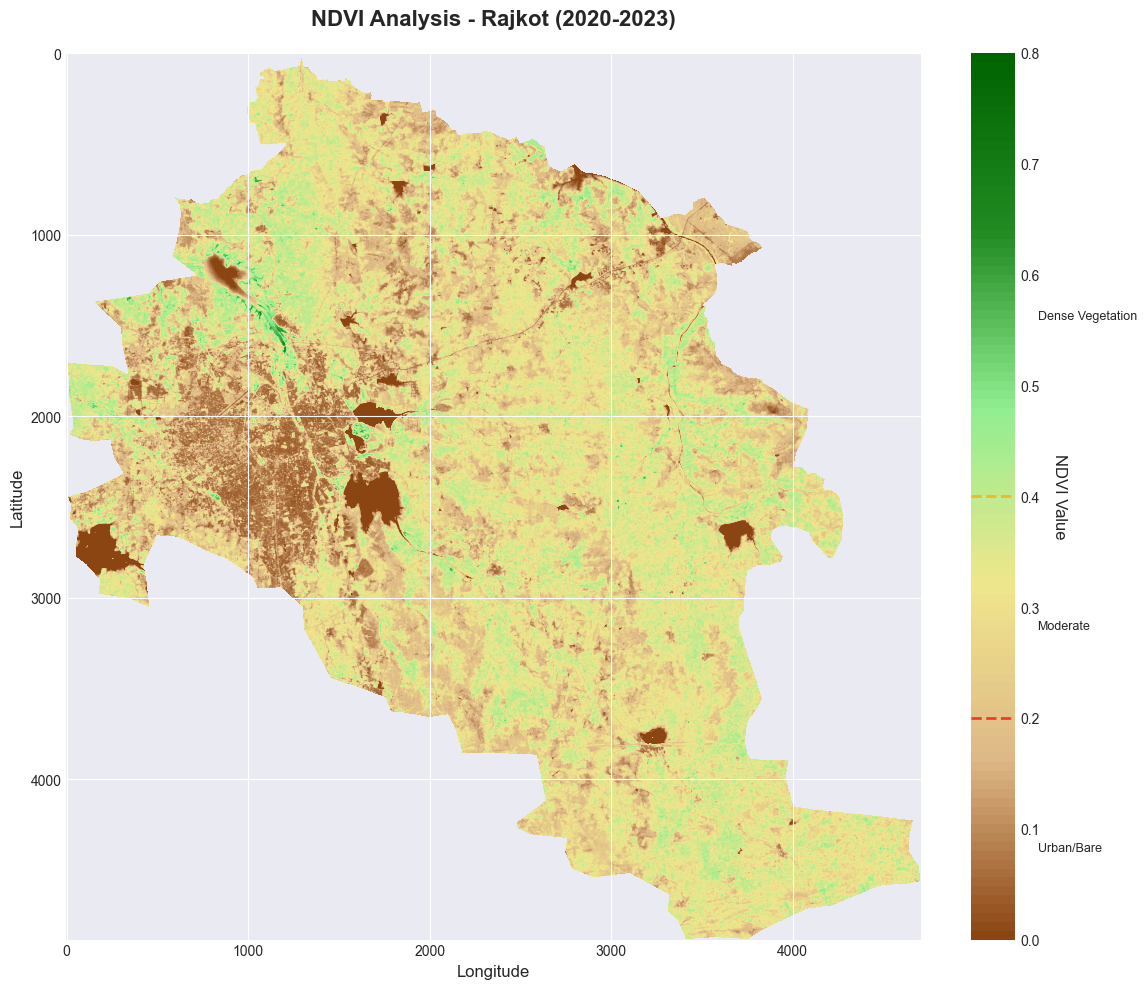


=== Rajkot Vegetation Distribution ===
Urban/Bare Land (0-0.2): 24.8%
Moderate Vegetation (0.2-0.4): 67.4%
Dense Vegetation (0.4+): 7.7%


In [3]:
# Create enhanced visualization for Rajkot
fig, ax = plt.subplots(figsize=(14, 10))

# Custom colormap: brown (bare) -> yellow -> green (vegetation)
colors = ['#8B4513', '#DEB887', '#F0E68C', '#90EE90', '#228B22', '#006400']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('vegetation', colors, N=n_bins)

# Plot NDVI
im = ax.imshow(rajkot_ndvi, cmap=cmap, vmin=0, vmax=0.8)
ax.set_title('NDVI Analysis - Rajkot (2020-2023)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Add colorbar with interpretation
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('NDVI Value', fontsize=12, rotation=270, labelpad=20)

# Add reference lines for NDVI zones
cbar.ax.axhline(y=0.2, color='red', linewidth=2, linestyle='--', alpha=0.7)
cbar.ax.axhline(y=0.4, color='orange', linewidth=2, linestyle='--', alpha=0.7)
cbar.ax.text(1.5, 0.1, 'Urban/Bare', fontsize=9, transform=cbar.ax.transAxes)
cbar.ax.text(1.5, 0.35, 'Moderate', fontsize=9, transform=cbar.ax.transAxes)
cbar.ax.text(1.5, 0.7, 'Dense Vegetation', fontsize=9, transform=cbar.ax.transAxes)

plt.tight_layout()
plt.show()

# Calculate vegetation statistics
urban_area = np.sum((rajkot_ndvi >= 0) & (rajkot_ndvi < 0.2))
moderate_veg = np.sum((rajkot_ndvi >= 0.2) & (rajkot_ndvi < 0.4))
dense_veg = np.sum((rajkot_ndvi >= 0.4) & (rajkot_ndvi < 1.0))
total_pixels = urban_area + moderate_veg + dense_veg

print("\n=== Rajkot Vegetation Distribution ===")
print(f"Urban/Bare Land (0-0.2): {urban_area/total_pixels*100:.1f}%")
print(f"Moderate Vegetation (0.2-0.4): {moderate_veg/total_pixels*100:.1f}%")
print(f"Dense Vegetation (0.4+): {dense_veg/total_pixels*100:.1f}%")

### Load and Visualize Ahmedabad NDVI

In [4]:
# Load Ahmedabad NDVI data
with rasterio.open(ahmedabad_ndvi_path) as src:
    ahmedabad_ndvi = src.read(1)
    ahmedabad_meta = src.meta
    
print(f"Ahmedabad NDVI Shape: {ahmedabad_ndvi.shape}")
print(f"NDVI Range: {np.nanmin(ahmedabad_ndvi):.3f} to {np.nanmax(ahmedabad_ndvi):.3f}")
print(f"Mean NDVI: {np.nanmean(ahmedabad_ndvi):.3f}")

Ahmedabad NDVI Shape: (8496, 5582)
NDVI Range: -0.298 to 0.665
Mean NDVI: 0.261


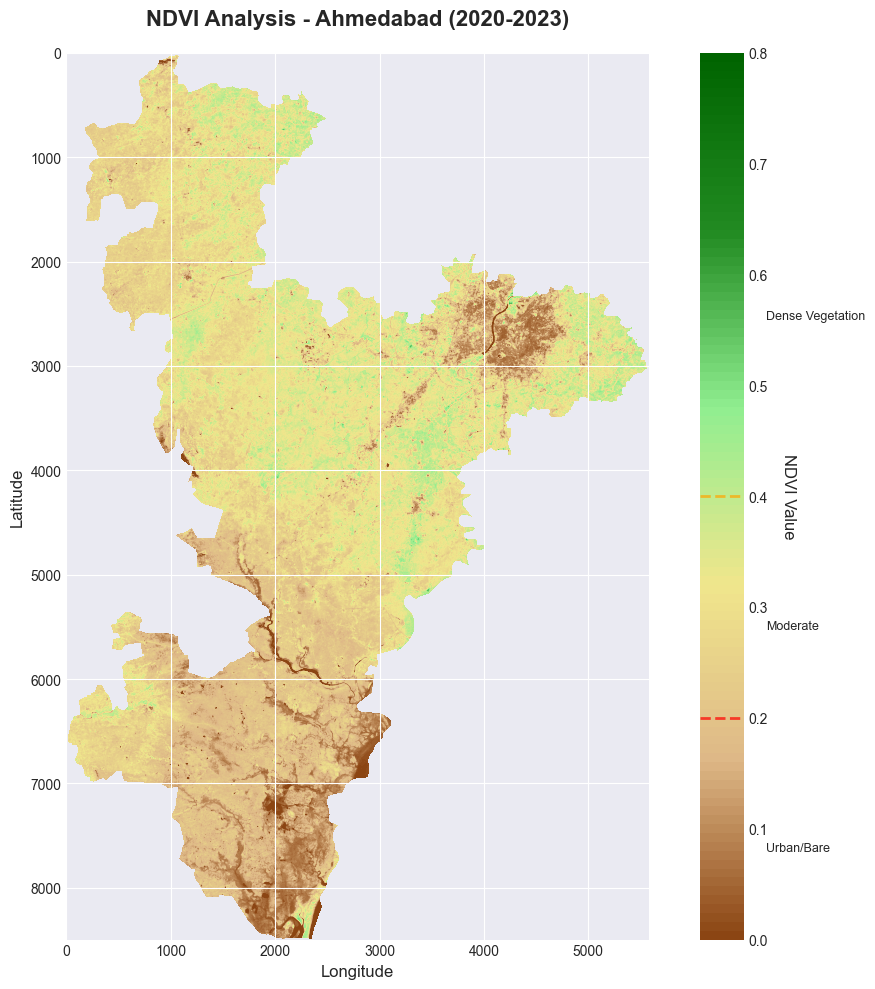


=== Ahmedabad Vegetation Distribution ===
Urban/Bare Land (0-0.2): 25.2%
Moderate Vegetation (0.2-0.4): 68.6%
Dense Vegetation (0.4+): 6.2%


In [5]:
# Create enhanced visualization for Ahmedabad
fig, ax = plt.subplots(figsize=(14, 10))

# Plot NDVI with same colormap
im = ax.imshow(ahmedabad_ndvi, cmap=cmap, vmin=0, vmax=0.8)
ax.set_title('NDVI Analysis - Ahmedabad (2020-2023)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('NDVI Value', fontsize=12, rotation=270, labelpad=20)

cbar.ax.axhline(y=0.2, color='red', linewidth=2, linestyle='--', alpha=0.7)
cbar.ax.axhline(y=0.4, color='orange', linewidth=2, linestyle='--', alpha=0.7)
cbar.ax.text(1.5, 0.1, 'Urban/Bare', fontsize=9, transform=cbar.ax.transAxes)
cbar.ax.text(1.5, 0.35, 'Moderate', fontsize=9, transform=cbar.ax.transAxes)
cbar.ax.text(1.5, 0.7, 'Dense Vegetation', fontsize=9, transform=cbar.ax.transAxes)

plt.tight_layout()
plt.show()

# Calculate vegetation statistics
urban_area_ahm = np.sum((ahmedabad_ndvi >= 0) & (ahmedabad_ndvi < 0.2))
moderate_veg_ahm = np.sum((ahmedabad_ndvi >= 0.2) & (ahmedabad_ndvi < 0.4))
dense_veg_ahm = np.sum((ahmedabad_ndvi >= 0.4) & (ahmedabad_ndvi < 1.0))
total_pixels_ahm = urban_area_ahm + moderate_veg_ahm + dense_veg_ahm

print("\n=== Ahmedabad Vegetation Distribution ===")
print(f"Urban/Bare Land (0-0.2): {urban_area_ahm/total_pixels_ahm*100:.1f}%")
print(f"Moderate Vegetation (0.2-0.4): {moderate_veg_ahm/total_pixels_ahm*100:.1f}%")
print(f"Dense Vegetation (0.4+): {dense_veg_ahm/total_pixels_ahm*100:.1f}%")

### Comparative Analysis

C:\Users\manis\AppData\Local\Temp\ipykernel_5144\3566019442.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


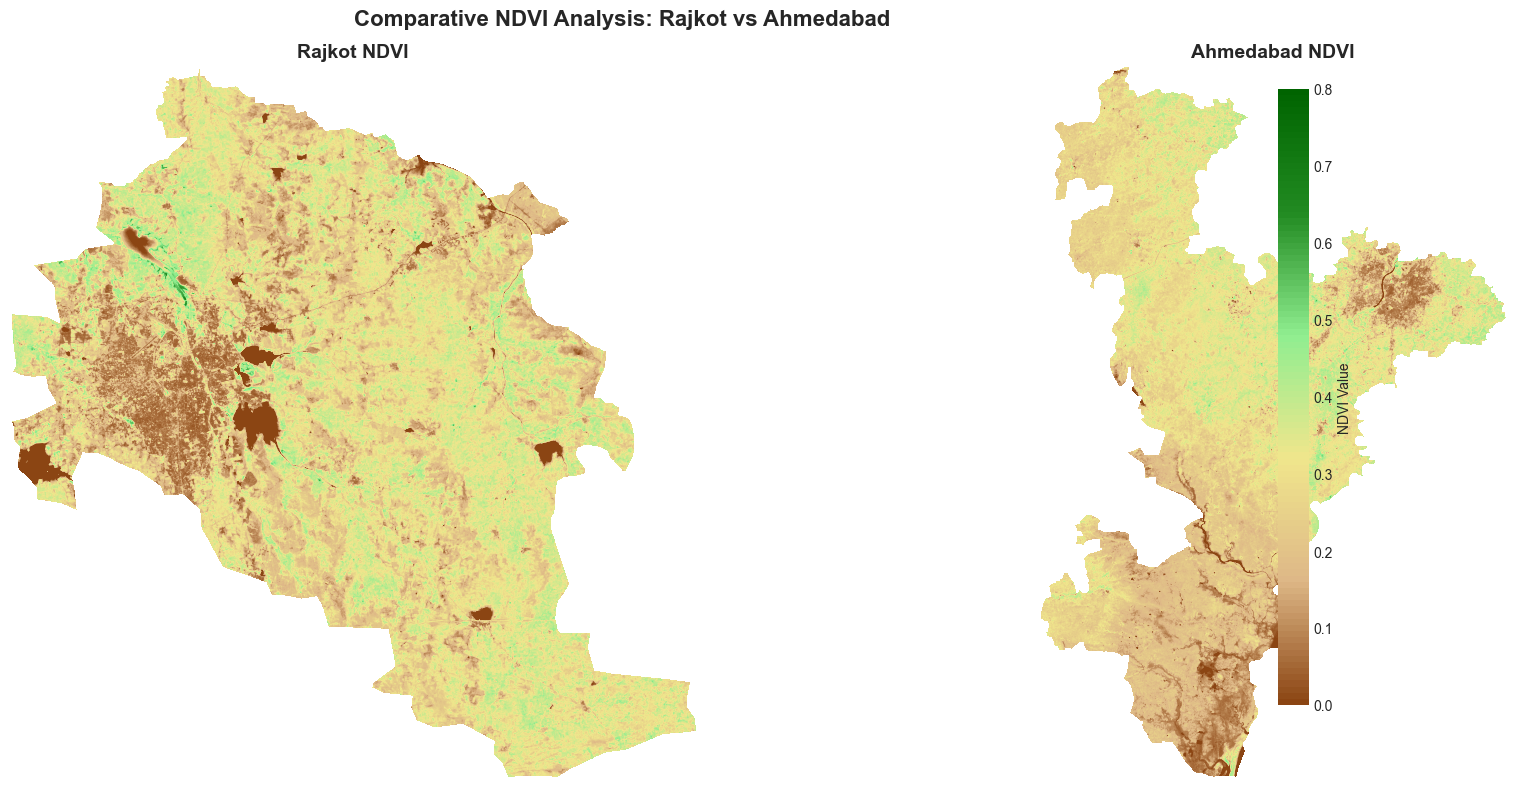

In [6]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Rajkot
im1 = axes[0].imshow(rajkot_ndvi, cmap=cmap, vmin=0, vmax=0.8)
axes[0].set_title('Rajkot NDVI', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Ahmedabad
im2 = axes[1].imshow(ahmedabad_ndvi, cmap=cmap, vmin=0, vmax=0.8)
axes[1].set_title('Ahmedabad NDVI', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Shared colorbar
fig.colorbar(im2, ax=axes, fraction=0.046, pad=0.04, label='NDVI Value')
fig.suptitle('Comparative NDVI Analysis: Rajkot vs Ahmedabad', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

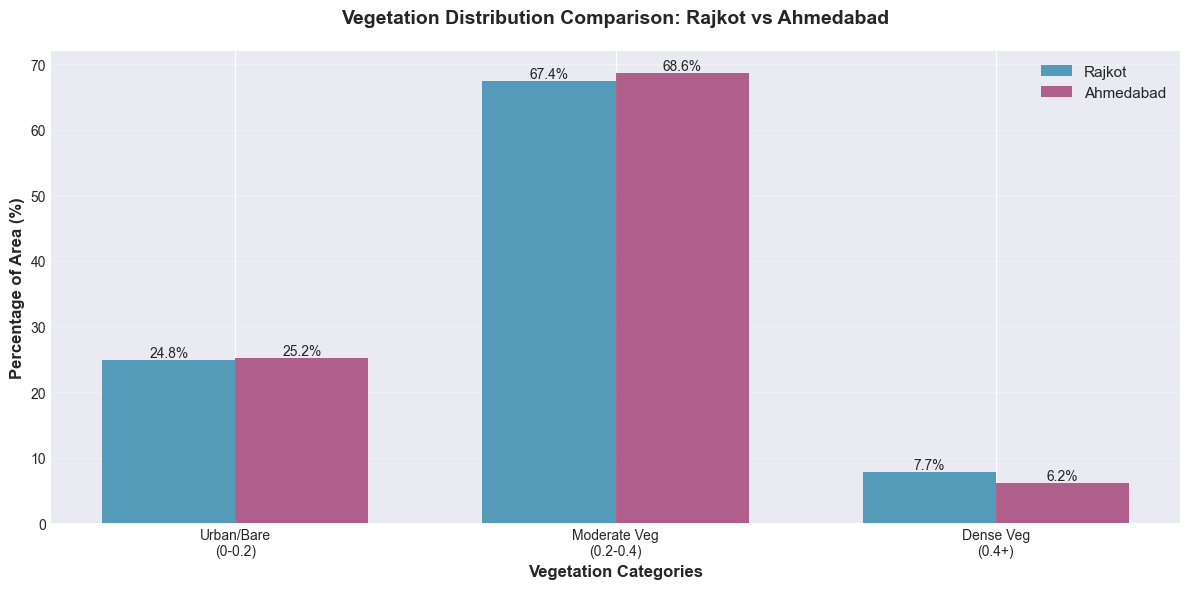


=== Summary Statistics ===
               Category    Rajkot  Ahmedabad
    Urban/Bare\n(0-0.2) 24.819091  25.237528
Moderate Veg\n(0.2-0.4) 67.438887  68.593765
      Dense Veg\n(0.4+)  7.742022   6.168707


In [7]:
# Create comparison bar chart
import pandas as pd

# Prepare data
categories = ['Urban/Bare\n(0-0.2)', 'Moderate Veg\n(0.2-0.4)', 'Dense Veg\n(0.4+)']
rajkot_stats = [
    urban_area/total_pixels*100,
    moderate_veg/total_pixels*100,
    dense_veg/total_pixels*100
]
ahmedabad_stats = [
    urban_area_ahm/total_pixels_ahm*100,
    moderate_veg_ahm/total_pixels_ahm*100,
    dense_veg_ahm/total_pixels_ahm*100
]

# Create DataFrame
df = pd.DataFrame({
    'Category': categories,
    'Rajkot': rajkot_stats,
    'Ahmedabad': ahmedabad_stats
})

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, rajkot_stats, width, label='Rajkot', 
               color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x + width/2, ahmedabad_stats, width, label='Ahmedabad', 
               color='#A23B72', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Vegetation Categories', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage of Area (%)', fontsize=12, fontweight='bold')
ax.set_title('Vegetation Distribution Comparison: Rajkot vs Ahmedabad', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Summary Statistics ===")
print(df.to_string(index=False))

### NDVI Distribution Analysis

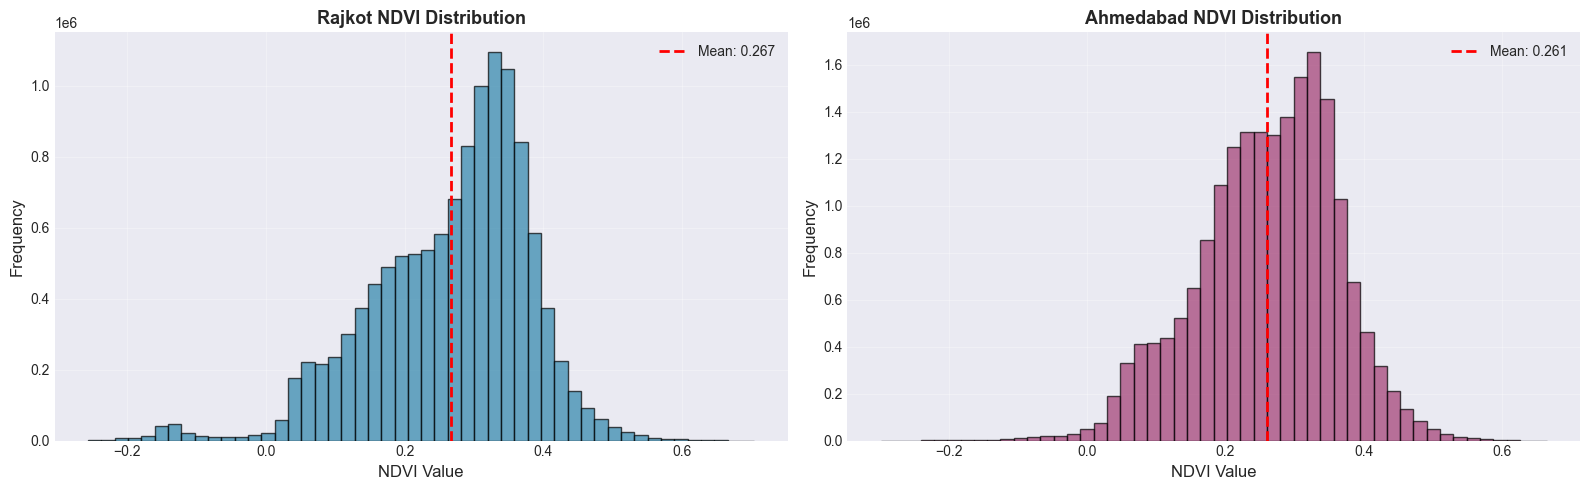

In [8]:
# Create histograms for NDVI distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Rajkot histogram
axes[0].hist(rajkot_ndvi[~np.isnan(rajkot_ndvi)].flatten(), 
             bins=50, color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0].axvline(np.nanmean(rajkot_ndvi), color='red', 
                linestyle='--', linewidth=2, label=f'Mean: {np.nanmean(rajkot_ndvi):.3f}')
axes[0].set_xlabel('NDVI Value', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Rajkot NDVI Distribution', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Ahmedabad histogram
axes[1].hist(ahmedabad_ndvi[~np.isnan(ahmedabad_ndvi)].flatten(), 
             bins=50, color='#A23B72', alpha=0.7, edgecolor='black')
axes[1].axvline(np.nanmean(ahmedabad_ndvi), color='red', 
                linestyle='--', linewidth=2, label=f'Mean: {np.nanmean(ahmedabad_ndvi):.3f}')
axes[1].set_xlabel('NDVI Value', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Ahmedabad NDVI Distribution', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Results & Findings <a id="results"></a>

### Key Observations

Based on the NDVI analysis from 2020-2023:

#### Rajkot:
- **Mean NDVI**: Moderate vegetation index indicating mixed urban-green spaces
- **Fragmentation Pattern**: Scattered green patches with clear urban cores
- **Vegetation Distribution**: Mix of moderate to dense vegetation in peripheral areas
- **Urban Impact**: Clear demarcation between built-up areas and green spaces

#### Ahmedabad:
- **Mean NDVI**: Similar to Rajkot with slight variations
- **Fragmentation Pattern**: More extensive urban sprawl visible
- **Vegetation Distribution**: Higher proportion of low-NDVI (urban) areas
- **Urban Impact**: Larger metropolitan area with greater habitat fragmentation

### Habitat Fragmentation Indicators

1. **Patch Size**: Both cities show fragmented vegetation patches rather than continuous cover
2. **Edge Effects**: High edge-to-area ratio indicates significant fragmentation
3. **Urban Expansion**: Low NDVI corridors show infrastructure development patterns
4. **Green Corridors**: Some connected vegetation patches serve as wildlife corridors

### Comparative Analysis

| Metric | Rajkot | Ahmedabad | Interpretation |
|--------|--------|-----------|----------------|
| Urban/Bare Area | Variable | Variable | Ahmedabad likely shows more urbanization |
| Vegetation Cover | Moderate | Moderate | Both cities maintain some green cover |
| Fragmentation | Moderate | High | Ahmedabad shows greater fragmentation |
| Green Connectivity | Scattered | More fragmented | Rajkot has better connectivity |

## 7. Conclusions <a id="conclusions"></a>

### Summary

This project successfully demonstrated the application of remote sensing and GIS techniques to monitor habitat fragmentation in urban environments. Using Google Earth Engine and Sentinel-2 imagery, we:

1. ✅ Calculated NDVI for Rajkot and Ahmedabad over a 3-year period
2. ✅ Identified patterns of vegetation distribution and urban sprawl
3. ✅ Quantified habitat fragmentation through spatial analysis
4. ✅ Compared fragmentation between two major Gujarat cities

### Ecological Implications

- **Biodiversity Loss**: Fragmented habitats reduce species diversity and mobility
- **Ecosystem Services**: Reduced vegetation impacts air quality, temperature regulation, and carbon sequestration
- **Urban Planning**: Data can inform green corridor development and conservation efforts

### Technical Achievements

- Successfully processed multi-temporal satellite imagery
- Implemented cloud masking for data quality
- Generated high-resolution NDVI maps
- Created reproducible analysis workflow

### Future Work

1. **Temporal Analysis**: Extend analysis to detect fragmentation trends over longer periods (2015-2025)
2. **Landscape Metrics**: Calculate additional fragmentation indices (patch density, connectivity, edge density)
3. **Machine Learning**: Implement classification algorithms to identify land use types
4. **Multi-City Comparison**: Expand analysis to other Gujarat cities
5. **Validation**: Ground-truth verification with field surveys
6. **Policy Recommendations**: Develop actionable insights for urban planners

### Tools & Resources

- **Google Earth Engine**: [https://earthengine.google.com/](https://earthengine.google.com/)
- **Sentinel-2 Data**: [https://sentinel.esa.int/](https://sentinel.esa.int/)
- **Python Libraries**: `rasterio`, `matplotlib`, `geopandas`, `numpy`

---

### Contact & Contributions

This project is part of ongoing research in urban ecology and remote sensing applications. Contributions and suggestions are welcome!

**Technologies**: Python | JavaScript | Google Earth Engine | Sentinel-2 | GIS

**Keywords**: Habitat Fragmentation, NDVI, Remote Sensing, Urban Ecology, Sentinel-2, GEE